# Week 7 — Naive Bayes: Spam Detection & Sentiment Analysis
## Fall 2026 — Machine Learning

## Student Information
**Name:** Ritika
**Student ID:** 023-24-0262
**Section:** H
**GitHub:**
**Kaggle:**
**Datasets:** SMS Spam Collection; Twitter US Airline Sentiment
**Dataset Sources:**
- Task A: Kaggle — https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset
- Task B: Kaggle — https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment

**Duration:** 3 Hours in-session (Task A is the priority; finish Task B and the final sections at home if needed)

> This notebook is a **template**, not a tutorial. You already know Naive Bayes theory. Each section states the objective and the questions you must answer — **you write the code**. Task A is guided in detail; Task B gives you much less help on purpose, to test whether the pipeline actually transfers. Every table, plot, and metric needs a short written observation.
>
> Submit **only this one notebook**. Keep every Markdown heading below — they are used for grading. Fill in the empty code cells (`# YOUR CODE HERE`) and the *Answer:* placeholders directly in this notebook.

---

## Setup

Import what you'll need. Add any other scikit-learn imports as you go.

In [23]:
# YOUR CODE HERE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay


---

## 1. Problem Definition & Dataset Exploration

*Concepts/functions you may find useful:* `pd.read_csv()`, `df.shape`, `df.head()`, `df['label'].value_counts()`

**Tasks**
1. Load both datasets (`spam.csv` for Task A, `Tweets.csv` for Task B). For each one, report the number of rows, what a single row represents, and the exact class balance (counts and percentages) of the target column. Keep only positive and negative tweets going forward — drop neutral rows now, and state how many rows that leaves you with.
2. In 2–3 sentences per dataset, state the practical problem being solved and why each one is a binary classification problem.

In [24]:
# Task 1 — load spam.csv, inspect shape/head/class balance
spam_df = pd.read_csv("scam/spam.csv", encoding="latin-1")


print("Shape:", spam_df.shape)

print("\nFirst 5 rows:")
display(spam_df.head())

print("\nColumn names:")
print(spam_df.columns.tolist())

print("\nClass counts:")
print(spam_df["v1"].value_counts())

print("\nClass percentages:")
print(
    (spam_df["v1"].value_counts(normalize=True) * 100).round(2)
)

Shape: (5572, 5)

First 5 rows:


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN



Column names:
['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']

Class counts:
v1
ham     4825
spam     747
Name: count, dtype: int64

Class percentages:
v1
ham     86.59
spam    13.41
Name: proportion, dtype: float64


In [25]:
### Task 1 (continued) — load Tweets.csv, drop neutral, inspect shape/head/class balance
twitter_df = pd.read_csv("twitter dataset/Tweets.csv")


print("Original shape:", twitter_df.shape)

print("\nFirst 5 rows:")
display(twitter_df.head())

print("\nColumn names:")
print(twitter_df.columns.tolist())

print("\nOriginal class counts:")
print(twitter_df["airline_sentiment"].value_counts())

print("\nOriginal class percentages:")
print(
    (twitter_df["airline_sentiment"].value_counts(normalize=True) * 100).round(2)
)


twitter_df = twitter_df[
    twitter_df["airline_sentiment"].isin(["positive", "negative"])
].copy()

print("\n\nTWITTER DATASET AFTER REMOVING NEUTRAL")


print("New shape:", twitter_df.shape)

print("\nNew class counts:")
print(twitter_df["airline_sentiment"].value_counts())

print("\nNew class percentages:")
print(
    (twitter_df["airline_sentiment"].value_counts(normalize=True) * 100).round(2)
)

Original shape: (14640, 15)

First 5 rows:


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)



Column names:
['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence', 'negativereason', 'negativereason_confidence', 'airline', 'airline_sentiment_gold', 'name', 'negativereason_gold', 'retweet_count', 'text', 'tweet_coord', 'tweet_created', 'tweet_location', 'user_timezone']

Original class counts:
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

Original class percentages:
airline_sentiment
negative    62.69
neutral     21.17
positive    16.14
Name: proportion, dtype: float64


TWITTER DATASET AFTER REMOVING NEUTRAL
New shape: (11541, 15)

New class counts:
airline_sentiment
negative    9178
positive    2363
Name: count, dtype: int64

New class percentages:
airline_sentiment
negative    79.53
positive    20.47
Name: proportion, dtype: float64


**Answer 2 (Task A — spam):**
The model predicts whether an SMS message is spam or a legitimate message (ham). This can support automatic spam filtering systems that decide which messages should be delivered normally or flagged as spam. It is a binary classification problem because there are two possible target classes: spam and ham.

**Answer 2 (Task B — sentiment):**
The model predicts whether an airline-related tweet expresses positive or negative sentiment. This can support airlines in monitoring customer opinions and identifying negative feedback. It is a binary classification problem because neutral tweets were removed, leaving only positive and negative classes.

---

## 2. Task A: Text Cleaning & Vectorization (Spam)

*Concepts/functions you may find useful:* `text.str.lower()`, `CountVectorizer` / `TfidfVectorizer`, `vectorizer.fit_transform(X_train)`, `vectorizer.transform(X_test)`, `vectorizer.get_feature_names_out()`

**Tasks**
3. Lightly clean the message text (lowercase at minimum). Keep this simple.
4. Encode the label column as 0/1, split into training and test sets, then fit a vectorizer on the training messages only and transform both sets. Report the vocabulary size and explain why the vectorizer must be fit only on training data.

In [26]:
# Task 3 — clean text

spam_df = spam_df.rename(columns={
    "v1": "label",
    "v2": "message"
})

spam_df["message"] = spam_df["message"].str.lower()

# Remove punctuation
spam_df["message"] = spam_df["message"].str.replace(
    r"[^\w\s]",
    "",
    regex=True
)

# Display cleaned messages
display(spam_df.head())

,label,message,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,go until jurong point crazy available only in ...,NaN,NaN,NaN
1,ham,ok lar joking wif u oni,NaN,NaN,NaN
2,spam,free entry in 2 a wkly comp to win fa cup fina...,NaN,NaN,NaN
3,ham,u dun say so early hor u c already then say,NaN,NaN,NaN
4,ham,nah i dont think he goes to usf he lives aroun...,NaN,NaN,NaN


In [27]:
# Task 4 — encode labels, split, fit vectorizer on train only, transform both sets

spam_df["label_encoded"] = spam_df["label"].map({
    "ham": 0,
    "spam": 1
})


X = spam_df["message"]
y = spam_df["label_encoded"]



X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)




vectorizer = TfidfVectorizer()

X_train_vec = vectorizer.fit_transform(X_train)

X_test_vec = vectorizer.transform(X_test)

# 8. Display results
print("Training vector shape:", X_train_vec.shape)
print("Testing vector shape:", X_test_vec.shape)


vocabulary = vectorizer.get_feature_names_out()

print("Vocabulary size:", len(vocabulary))

print("\nFirst 20 vocabulary words:")
print(vocabulary[:20])

Training vector shape: (4457, 8347)
Testing vector shape: (1115, 8347)
Vocabulary size: 8347

First 20 vocabulary words:
['008704050406' '0089my' '0121' '01223585236' '01223585334' '02' '020603'
 '0207' '02070836089' '02072069400' '02073162414' '02085076972' '020903'
 '021' '050703' '0578' '06' '060505' '061104' '07008009200']


**Answer 4 (why fit on training data only):**
We fit the TF-IDF vectorizer only on the training data so that the model does not learn any information from the test data. If we fit it on both training and testing data, it can cause data leakage, making the evaluation less reliable. The test data should remain completely unseen until we evaluate the final model.

---

## 3. Task A: Naive Bayes Model & Evaluation (Spam)

*Concepts/functions you may find useful:* `MultinomialNB()`, `.fit()`, `.predict()`, `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `confusion_matrix`

**Tasks**
5. Train a `MultinomialNB` model on the vectorized training data. Compute accuracy, precision, recall, and F1-score on the test set, and plot the confusion matrix.
6. Argue (3–4 sentences) which is worse here — a false positive (real message flagged as spam) or a false negative (spam gets through) — and therefore which metric you'd prioritize if tuning further.

Accuracy: 0.9515695067264573
Precision: 1.0
Recall: 0.6375838926174496
F1-score: 0.7786885245901639

Confusion Matrix:
[[966   0]
 [ 54  95]]


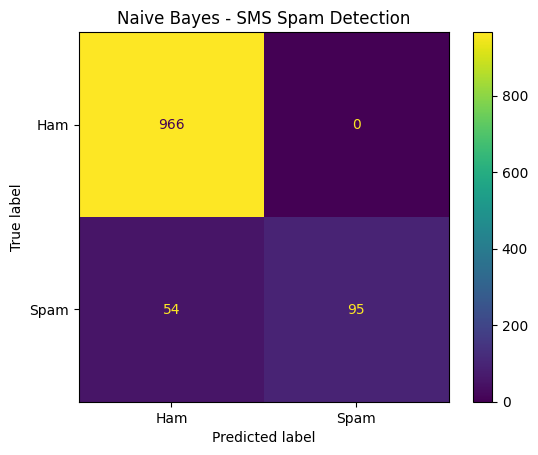

In [28]:
# Task 5 — train MultinomialNB, compute metrics, plot confusion matrix

nb_model = MultinomialNB()

nb_model.fit(X_train_vec, y_train)

y_pred = nb_model.predict(X_test_vec)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Ham", "Spam"]
)

disp.plot()
plt.title("Naive Bayes - SMS Spam Detection")
plt.show()

**Task 5 — Spam Model Metrics**

| Metric | Value |
|---|---|
| Accuracy | 0.95|
| Precision | 1.00|
| Recall |0.63 |
| F1-score | 0.77|

**Answer 6:**
In spam detection, both false positives and false negatives can cause problems. A false positive can cause an important legitimate message to be incorrectly classified as spam, while a false negative allows a spam message to reach the user's inbox. Therefore, precision is important for avoiding false positives, while recall is important for detecting as much spam as possible. In this model, precision is 100%, but recall is 63.76%, showing that the model avoids false spam predictions but misses some actual spam messages.

---

## 4. Task A: Word Interpretation (Spam)

*Concepts/functions you may find useful:* `model.feature_log_prob_`, `np.argsort(...)`

**Tasks**
7. Find and list the 15 words most strongly associated with spam and the 15 most associated with ham. Do these match your intuition?
8. Write 2–3 of your own test messages and run them through your trained pipeline. Do the predictions match what you expected?

In [29]:
# Task 7 — extract top spam words and top ham words from feature_log_prob_

log_prob_ham = nb_model.feature_log_prob_[0]
log_prob_spam = nb_model.feature_log_prob_[1]

log_prob_diff = log_prob_spam - log_prob_ham


spam_indices = np.argsort(log_prob_diff)[-15:][::-1]

ham_indices = np.argsort(log_prob_diff)[:15]

print("15 words most associated with SPAM:")
for i in spam_indices:
    print(vocabulary[i], log_prob_diff[i])

print("\n15 words most associated with HAM:")
for i in ham_indices:
    print(vocabulary[i], log_prob_diff[i])

15 words most associated with SPAM:
claim 3.457098064592949
prize 3.23571909230517
won 3.1134775524366827
urgent 2.784886992912126
guaranteed 2.776106781869977
nokia 2.7402418057175613
500 2.734555818567352
1000 2.721254660821593
tone 2.6842882548547227
18 2.6598552966474536
txt 2.593366614567583
16 2.5556624148988085
awarded 2.5368752253013795
service 2.531687984025794
150ppm 2.5218276986075745

15 words most associated with HAM:
ill -3.3397148294541577
my -3.243269042319593
ltgt -3.1568936406771115
ok -3.1257327915637836
later -3.0475529823286465
lor -2.9839324495987496
im -2.911994952187402
come -2.875839204345687
home -2.850688319101568
but -2.8432623121610305
da -2.8329597074269097
sorry -2.762814463134572
me -2.722458142169118
he -2.5937194580992884
going -2.567719700949164


**Answer 7:**
The Naive Bayes model identified words such as “claim,” “prize,” “won,” “urgent,” and “guaranteed” as strongly associated with spam. These words are commonly related to promotional or prize-based messages. Words such as “ill,” “my,” “ok,” “later,” and “home” were more strongly associated with ham, which reflects casual personal conversations. This shows that the model learned useful differences in vocabulary between spam and legitimate messages.

In [30]:
# Task 8 — test your own messages
my_messages = [
   "Congratulations! You have won a cash prize. Claim your reward now!",
    "Hey, are you coming to class tomorrow?",
    "URGENT! You have been selected for a free prize. Call now to claim it."
]
my_messages_clean = [
    message.lower() for message in my_messages
]

my_messages_vec = vectorizer.transform(my_messages_clean)

new_predictions = nb_model.predict(my_messages_vec)


for message, prediction in zip(my_messages, new_predictions):
    label = "Spam" if prediction == 1 else "Ham"
    print("Message:", message)
    print("Prediction:", label)
    print()

Message: Congratulations! You have won a cash prize. Claim your reward now!
Prediction: Spam

Message: Hey, are you coming to class tomorrow?
Prediction: Ham

Message: URGENT! You have been selected for a free prize. Call now to claim it.
Prediction: Spam



**Answer 8:**
The trained Naive Bayes model correctly classified the three new messages according to their content. The two messages containing words such as “prize,” “won,” “claim,” and “urgent” were classified as spam. The casual message about coming to class was classified as ham. This demonstrates that the model can use learned vocabulary patterns to classify previously unseen messages.

---

## 5. Task A: Kaggle Notebook Submission

Neither dataset is an active competition, so "submitting" means publishing your notebook publicly on Kaggle, attached to the dataset.

**Tasks**
9. Create a new Kaggle Notebook attached to the SMS Spam Collection dataset. Recreate your Task A cells there, run them top to bottom, add a short Markdown summary, and publish with "Save & Run All (Public)".
10. Record the public notebook URL below.

**Task A Kaggle Notebook URL:**
https://www.kaggle.com/code/ritikalund/sms-spam-detection-naive-bayes-lab-7

---

## 6. Task B: Text Cleaning & Vectorization (Sentiment)

Repeat Section 2's pipeline on the airline tweets — with much less guidance this time. Tweets contain @mentions, links, and hashtags that SMS messages didn't.

**Tasks**
11. Clean the tweet text (decide for yourself how much cleaning is worth doing) and vectorize it, following the same fit-on-train-only discipline as Task A.
12. Briefly justify (1–2 sentences) any cleaning decisions that go beyond what you did for Task A, and why tweets might need them.

In [31]:
# Task 11 — clean and vectorize the sentiment data (your own approach)
import re

twitter_df = twitter_df.copy()

twitter_df = twitter_df[
    twitter_df["airline_sentiment"].isin(["positive", "negative"])
].copy()

twitter_df["text"] = twitter_df["text"].str.lower()


twitter_df["text"] = twitter_df["text"].str.replace(
    r"@\w+",
    "",
    regex=True
)


twitter_df["text"] = twitter_df["text"].str.replace(
    r"http\S+|www\S+",
    "",
    regex=True
)

twitter_df["text"] = twitter_df["text"].str.replace(
    "#",
    "",
    regex=False
)

twitter_df["text"] = twitter_df["text"].str.replace(
    r"[^\w\s]",
    "",
    regex=True
)

twitter_df["text"] = twitter_df["text"].str.replace(
    r"\s+",
    " ",
    regex=True
).str.strip()


twitter_df["sentiment_encoded"] = twitter_df["airline_sentiment"].map({
    "negative": 0,
    "positive": 1
})


X_twitter = twitter_df["text"]
y_twitter = twitter_df["sentiment_encoded"]

# Split into training and testing data
X_train_twitter, X_test_twitter, y_train_twitter, y_test_twitter = train_test_split(
    X_twitter,
    y_twitter,
    test_size=0.2,
    random_state=42,
    stratify=y_twitter
)

twitter_vectorizer = TfidfVectorizer()

X_train_twitter_vec = twitter_vectorizer.fit_transform(
    X_train_twitter
)


X_test_twitter_vec = twitter_vectorizer.transform(
    X_test_twitter
)


twitter_vocabulary = twitter_vectorizer.get_feature_names_out()

# Display results
print("Training vector shape:", X_train_twitter_vec.shape)
print("Testing vector shape:", X_test_twitter_vec.shape)
print("Vocabulary size:", len(twitter_vocabulary))

print("\nFirst 20 vocabulary words:")
print(twitter_vocabulary[:20])

print("\nClass counts:")
print(twitter_df["airline_sentiment"].value_counts())

Training vector shape: (9232, 11138)
Testing vector shape: (2309, 11138)
Vocabulary size: 11138

First 20 vocabulary words:
['0016' '0162389030167' '0162424965446' '0162431184663' '0214' '021mbps'
 '022015' '0223' '02282015' '03' '0303' '03032015' '0316' '0372389047497'
 '0510' '0600' '0671' '10' '100' '1000']

Class counts:
airline_sentiment
negative    9178
positive    2363
Name: count, dtype: int64


**Answer 12:**
Tweets require extra cleaning because they commonly contain @mentions, URLs, and hashtags that may add noise to the text classification. Therefore, these elements were removed or cleaned so that the model can focus more on the actual words expressing sentiment.


---

## 7. Task B: Naive Bayes Model & Evaluation (Sentiment)

**Tasks**
13. Train a `MultinomialNB` model on the vectorized tweet data. Compute accuracy, precision, recall, and F1-score, and plot the confusion matrix.
14. Compare these metrics to Task A's. Did Naive Bayes do better or worse on sentiment than on spam? Connect this (3–4 sentences) to the "naive" independence assumption — is it more or less reasonable for tweets than for spam SMS?

Accuracy: 0.8284971849285405
Precision: 1.0
Recall: 0.16279069767441862
F1-score: 0.28

Confusion Matrix:
[[1836    0]
 [ 396   77]]


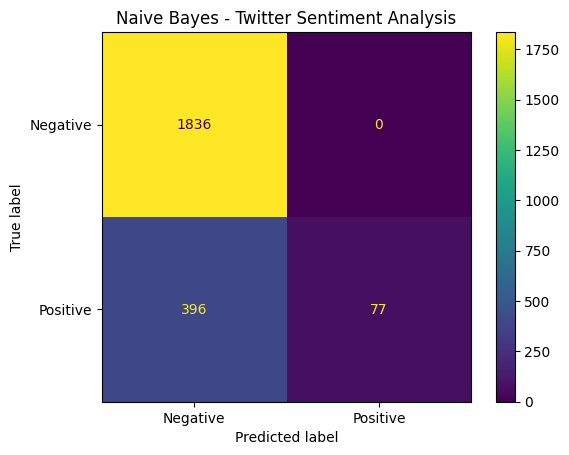

In [32]:
# Task 13 — train MultinomialNB, compute metrics, plot confusion matrix

twitter_nb_model = MultinomialNB()


twitter_nb_model.fit(
    X_train_twitter_vec,
    y_train_twitter
)


y_pred_twitter = twitter_nb_model.predict(
    X_test_twitter_vec
)


twitter_accuracy = accuracy_score(
    y_test_twitter,
    y_pred_twitter
)

twitter_precision = precision_score(
    y_test_twitter,
    y_pred_twitter
)

twitter_recall = recall_score(
    y_test_twitter,
    y_pred_twitter
)

twitter_f1 = f1_score(
    y_test_twitter,
    y_pred_twitter
)


print("Accuracy:", twitter_accuracy)
print("Precision:", twitter_precision)
print("Recall:", twitter_recall)
print("F1-score:", twitter_f1)


twitter_cm = confusion_matrix(
    y_test_twitter,
    y_pred_twitter
)

print("\nConfusion Matrix:")
print(twitter_cm)


disp = ConfusionMatrixDisplay(
    confusion_matrix=twitter_cm,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("Naive Bayes - Twitter Sentiment Analysis")
plt.show()

**Task 13 — Sentiment Model Metrics**

| Metric | Value |
|---|---|
| Accuracy | 0.82|
| Precision | 1.00|
| Recall | 0.16|
| F1-score | 0.28|

**Answer 14:**
The Naive Bayes model performed differently on the two datasets. For SMS spam detection, it achieved 95.16% accuracy and 77.87% F1-score, while for Twitter sentiment analysis it achieved 82.85% accuracy and 28.00% F1-score. Both models achieved 100% precision, but the Twitter model had much lower recall at 16.28% compared with 63.76% for SMS spam. This difference may be because spam messages often contain strong words associated with spam, while sentiment in tweets can depend more on context, informal language, and expressions. Naive Bayes assumes that features are conditionally independent given the class, meaning that it treats the presence of individual words as independent when making predictions. This assumption is not completely true for natural language because the meaning of a word can depend on other words in the sentence, but Naive Bayes can still work effectively as a text classification method.

---

## 8. Task B: Kaggle Notebook Submission

**Tasks**
15. Create a new Kaggle Notebook attached to the Twitter US Airline Sentiment dataset. Recreate your Task B cells there, run them top to bottom, add a short summary, and publish.
16. Record the public notebook URL below.

**Task B Kaggle Notebook URL:**
https://www.kaggle.com/code/ritikalund/twitter-sentiment-analysis-task-b

---

## 9. Cross-Task Comparison & vs. Logistic Regression

*Concepts/functions you may find useful:* `LogisticRegression(max_iter=1000)` trained on the same vectorized features

**Tasks**
17. Build a table comparing Naive Bayes on Task A vs. Task B (accuracy, precision, recall, F1).
18. Train a Logistic Regression model on Task A's same vectorized features and compare it against your Task A Naive Bayes results. Which model wins, and does that match what you'd expect?

**Task 17 — Task A vs. Task B (Naive Bayes)**

| Metric | Task A (Spam) | Task B (Sentiment) |
|---|---|---|
| Accuracy |0.95| 0.82|
| Precision |1.00 |1.00 |
| Recall |0.63 |0.16 |
| F1-score |0.77 |0.28 |

In [33]:
# Task 18 — train Logistic Regression on Task A's vectorized features
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)


lr_model.fit(
    X_train_vec,
    y_train
)


lr_pred = lr_model.predict(
    X_test_vec
)

lr_accuracy = accuracy_score(
    y_test,
    lr_pred
)

lr_precision = precision_score(
    y_test,
    lr_pred
)

lr_recall = recall_score(
    y_test,
    lr_pred
)

lr_f1 = f1_score(
    y_test,
    lr_pred
)

print("Logistic Regression Results")
print("Accuracy:", lr_accuracy)
print("Precision:", lr_precision)
print("Recall:", lr_recall)
print("F1-score:", lr_f1)

print("\nNaive Bayes Results")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Logistic Regression Results
Accuracy: 0.9659192825112107
Precision: 0.9911504424778761
Recall: 0.7516778523489933
F1-score: 0.8549618320610687

Naive Bayes Results
Accuracy: 0.9515695067264573
Precision: 1.0
Recall: 0.6375838926174496
F1-score: 0.7786885245901639


**Task 18 — Naive Bayes vs. Logistic Regression (Task A)**

| Metric | Naive Bayes | Logistic Regression |
|---|---|---|
| Accuracy |0.95 |0.96 |
| Precision |1.00 0.99| |
| Recall |0.63 |0.75 |
| F1-score |0.77 |0.85 |

**Answer 18 (which wins, and does it match expectations):**
Logistic Regression performed better than Naive Bayes on accuracy, recall, and F1-score, achieving 96.59% accuracy, 75.17% recall, and 85.50% F1-score. Naive Bayes achieved slightly higher precision at 100%, compared with 99.12% for Logistic Regression. Therefore, the models show a trade-off: Logistic Regression detected more actual spam messages, while Naive Bayes made slightly more precise spam predictions. These results are consistent with the expectation that different classification algorithms can perform differently even when trained on the same TF-IDF features. The comparison also shows why accuracy alone should not be used to evaluate a spam classifier.

---

## 10. Final Reflection & Conclusion

**Tasks**
19. Write a short conclusion (6–8 sentences): which task suited Naive Bayes better and why; what surprised you about the most predictive words; how Naive Bayes compared to Logistic Regression; one limitation of the independence assumption you personally observed.
20. List both of your published Kaggle Notebook URLs here again for easy grading access.

**Answer 19 — Conclusion:**
In this lab, Multinomial Naive Bayes was used for both SMS spam detection and Twitter sentiment classification. The SMS model achieved 95.16% accuracy, 100% precision, 63.76% recall, and a 77.87% F1-score. The Twitter model achieved 82.85% accuracy, 100% precision, 16.28% recall, and a 28.00% F1-score, showing that sentiment classification was more challenging with this setup. TF-IDF helped convert text into numerical features that could be used by the machine learning models. The results also showed that Naive Bayes learned useful word patterns, such as spam-related words like “claim,” “prize,” and “urgent.” On the SMS dataset, Logistic Regression achieved higher accuracy, recall, and F1-score than Naive Bayes, although Naive Bayes had slightly higher precision. Overall, the lab demonstrated how text cleaning, TF-IDF vectorization, and different classification algorithms can affect the performance of text classification models.


**Answer 20 — Kaggle Notebook Links:**
- Task A: https://www.kaggle.com/code/ritikalund/sms-spam-detection-naive-bayes-lab-7
- Task B: https://www.kaggle.com/code/ritikalund/twitter-sentiment-analysis-task-b

---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Filled in the student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, both datasets)
- [ ] Section 1 — Problem Definition & Dataset Exploration (both datasets, neutral tweets dropped)
- [ ] Section 2 — Task A Cleaning & Vectorization (fit on training data only)
- [ ] Section 3 — Task A Model & Evaluation (all four metrics + confusion matrix + precision/recall argument)
- [ ] Section 4 — Task A Word Interpretation (top words + your own test messages)
- [ ] Section 5 — Task A Kaggle Notebook published and linked
- [ ] Section 6 — Task B Cleaning & Vectorization (cleaning choices justified)
- [ ] Section 7 — Task B Model & Evaluation (all four metrics + independence-assumption discussion)
- [ ] Section 8 — Task B Kaggle Notebook published and linked
- [ ] Section 9 — Cross-Task Comparison & vs. Logistic Regression
- [ ] Section 10 — Final Reflection & Conclusion (both Kaggle links listed again)
- [ ] Notebook exported/shared as a single Colab (.ipynb) file — no other files submitted